In [37]:
#📦 Core Libraries
import os
import cv2 as cv
import numpy as np
import pandas as pd

#🧠 Machine Learning Libraries                    
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from dicionario_SIFT import artefatos_sift, load_images_from_folder

# 📊 Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Grupos de features

In [38]:
lista_descritores = np.load('lista_sift.npz')["lista_descritores"]
lista_descritores = pd.DataFrame(lista_descritores)

In [39]:
kmeans = KMeans(n_clusters=10, random_state=0).fit(lista_descritores)
print(kmeans.cluster_centers_)

[[20.353642  16.018438  12.906467  ...  5.746705   6.3526106 21.948317 ]
 [65.084885  38.821777  13.879278  ...  9.974243   7.801259  14.296763 ]
 [23.682995  14.093749  10.516691  ... 11.684763   8.928069  19.286013 ]
 ...
 [30.782282  34.829533  30.681782  ... 12.37758   15.713222  23.603952 ]
 [18.86336   17.055082  17.771997  ... 18.817049  18.877087  21.782925 ]
 [33.59326   33.65289   28.649101  ... 10.339493  10.905724  17.51773  ]]


In [40]:
dic_imges = load_images_from_folder(r'datasets')
sift = artefatos_sift(dic_imges)
list_descritores = sift[0]
dic_features = sift[1]

In [41]:
dic_features.keys()

dict_keys(['Apes', 'Owls'])

In [42]:
dic_histogram = {}
features = []
labels_list = []
for i, _ in dic_features.items():
    
    for index, img in enumerate(_):
        lista_hist = []
        descritor = dic_features[i][index]
        labels = kmeans.predict(descritor)
        histograma, _ = np.histogram(labels, bins = np.arange(kmeans.n_clusters + 1))
        lista_hist.append(histograma)
        features.append(histograma)
        labels_list.append(0 if i == "Apes" else 1)


    dic_histogram[i] = lista_hist
print(dic_histogram)

{'Apes': [array([144, 130, 223, 174,  96, 166, 179, 196, 210, 213])], 'Owls': [array([136, 149, 258, 361, 282, 147, 419, 145, 131, 128])]}


In [43]:
dic_histogram.keys()

dict_keys(['Apes', 'Owls'])

# Treinamento SVM

In [44]:
X_train, X_test, y_train, y_test = train_test_split(features, labels_list, test_size=0.2, random_state=42)

In [45]:
model = SVC()
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [46]:
y_predict = model.predict(X_test)

In [47]:
y_predict

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [48]:
y_test

[0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0]

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , confusion_matrix
print(f"accuracy_score: {accuracy_score(y_test, y_predict)}")
print(f"precision: {precision_score(y_test, y_predict, average='macro')}")
print(f"recall: {recall_score(y_test, y_predict, average='macro')}")

accuracy_score: 0.9090909090909091
precision: 0.9375
recall: 0.875


Text(0.5, 36.72222222222221, 'Predicted')

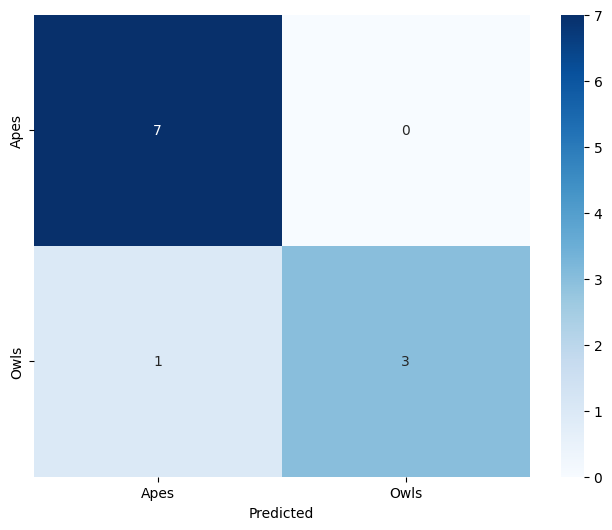

In [50]:
matrix = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Apes', 'Owls'], yticklabels=['Apes', 'Owls'])
plt.xlabel('Predicted')
